In [1]:
# Cell 1: Setting up the python packages 
import pandas as pd
import voltaiq_studio as vs

SOC_series = (100,95,90,80,70,60,50,40,30,20,10,5,0)
current = 42.5

# 1. Get the test records currently loaded or accessible
trs = vs.get_test_records()

# 2. Filter for both target test records (update name fragments)
def filter_test_record_by_name(name):
    return [t for t in trs if name.lower() in t.name.lower()]


In [2]:
trs = vs.get_test_records()

def filter_test_record_by_name(name_fragment):
    return [t for t in trs if name_fragment.lower() in t.name.lower()]

test_names = [
             'CV_0010_CS2D0052_Pr_FastGITT_15C',
             'CV_0010_CS2D9049_Pr_FastGITT_15C',
             ]
filtered_trs = []
for name in test_names:
    filtered_trs.extend(filter_test_record_by_name(name))

In [3]:
print(len(filtered_trs))
for tr in filtered_trs:
    print(tr.name)

2
CV_0010_CS2D0052_Pr_FastGITT_15C
CV_0010_CS2D9049_Pr_FastGITT_15C


In [4]:
for tr in filtered_trs:
    reader = tr.make_time_series_reader()
    reader.add_trace_keys('h_cycle','h_step_index')
    df = reader.read_pandas()

    combos = df[['h_cycle','h_step_index']].drop_duplicates()
    print(tr.name)
    print(combos.sort_values(['h_cycle','h_step_index']).tail(50))

CV_0010_CS2D0052_Pr_FastGITT_15C
        h_cycle  h_step_index
399398      2.0          40.0
424600      2.0          41.0
426052      2.0          42.0
451254      2.0          43.0
451981      2.0          44.0
477183      2.0          45.0
478262      2.0          46.0
503464      2.0          47.0
504666      3.0          47.0
505868      4.0          47.0
507070      4.0          49.0
507797      4.0          50.0
532999      4.0          51.0
533726      4.0          52.0
558928      4.0          53.0
560379      4.0          54.0
585581      4.0          55.0
587757      4.0          56.0
612959      4.0          57.0
615135      4.0          58.0
640337      4.0          59.0
643961      4.0          60.0
654763      4.0          61.0
658387      4.0          62.0
669189      4.0          63.0
676435      4.0          64.0
687237      4.0          65.0
694483      4.0          66.0
705285      4.0          67.0
712531      4.0          68.0
723335      4.0          69.0
730581 

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic: verify discharge step lookups and df_hysteresis contents
# ─────────────────────────────────────────────────────────────────────────────

discharge_map_check = {
    (4,57):99, (4,59):98, (4,61):96, (4,63):93, (4,65):90,
    (4,67):85, (4,69):80, (4,71):70, (4,73):60, (4,75):50,
    (4,77):40, (4,79):30, (4,81):20, (4,83):15, (4,85):10,
    (4,87):7,  (4,89):4,  (4,91):2,  (4,93):1,  (4,95):0
}

tr = filtered_trs[0]
reader = tr.make_time_series_reader()
reader.add_trace_keys('aux_neware_xls_voltage_volt_0', 'h_cycle', 'h_step_index')
df_diag = reader.read_pandas()
df_diag = df_diag.sort_values(['h_cycle', 'h_step_index']).reset_index(drop=True)

print(f"h_cycle dtype     : {df_diag['h_cycle'].dtype}")
print(f"h_step_index dtype: {df_diag['h_step_index'].dtype}")
print()

print("── Discharge step lookup results ──────────────────────────────────────")
for (cycle, step), soc in sorted(discharge_map_check.items(), key=lambda x: x[1]):
    mask = (df_diag['h_cycle'] == cycle) & (df_diag['h_step_index'] == step)
    step_data = df_diag[mask]
    if step_data.empty:
        print(f"  SOC {soc:3d}%  (cycle={cycle}, step={step:2d})  →  ❌ NOT FOUND")
    else:
        v = step_data.iloc[-1]['aux_neware_xls_voltage_volt_0']
        print(f"  SOC {soc:3d}%  (cycle={cycle}, step={step:2d})  →  ✅  V = {v:.6f} V  ({len(step_data)} rows)")

print()
print("── df_hysteresis discharge coverage ───────────────────────────────────")
discharge_in_df = df_hysteresis.dropna(subset=["v_discharge_V"])["soc_percent"].unique()
print(f"  SOC points with discharge data: {sorted(discharge_in_df)}")
print(f"  Missing vs discharge_map      : {sorted(set(discharge_map_check.values()) - set(discharge_in_df))}")
print()
print(f"  Total rows in df_hysteresis   : {len(df_hysteresis)}")
print(f"  Rows with v_discharge_V       : {df_hysteresis['v_discharge_V'].notna().sum()}")
print(f"  Rows with in_both == True     : {(df_hysteresis['in_both'] == True).sum()}")

h_cycle dtype     : float64
h_step_index dtype: float64

── Discharge step lookup results ──────────────────────────────────────
  SOC   0%  (cycle=4, step=95)  →  ❌ NOT FOUND
  SOC   1%  (cycle=4, step=93)  →  ❌ NOT FOUND
  SOC   2%  (cycle=4, step=91)  →  ❌ NOT FOUND
  SOC   4%  (cycle=4, step=89)  →  ❌ NOT FOUND
  SOC   7%  (cycle=4, step=87)  →  ✅  V = 1.499984 V  (2588 rows)
  SOC  10%  (cycle=4, step=85)  →  ✅  V = 1.993423 V  (728 rows)
  SOC  15%  (cycle=4, step=83)  →  ✅  V = 2.070310 V  (1452 rows)
  SOC  20%  (cycle=4, step=81)  →  ✅  V = 2.185964 V  (2176 rows)
  SOC  30%  (cycle=4, step=79)  →  ✅  V = 2.311169 V  (2176 rows)
  SOC  40%  (cycle=4, step=77)  →  ✅  V = 2.413090 V  (3624 rows)
  SOC  50%  (cycle=4, step=75)  →  ✅  V = 2.561348 V  (3626 rows)
  SOC  60%  (cycle=4, step=73)  →  ✅  V = 2.681733 V  (7246 rows)
  SOC  70%  (cycle=4, step=71)  →  ✅  V = 2.823110 V  (7246 rows)
  SOC  80%  (cycle=4, step=69)  →  ✅  V = 2.942697 V  (7246 rows)
  SOC  85%  (cycle=4, st

NameError: name 'df_hysteresis' is not defined

In [6]:
import pandas as pd
import numpy as np

def calculate_gitt_hysteresis(filtered_trs):

    discharge_map = {
        (4,50):99, (4,52):98, (4,54):96, (4,56):93, (4,58):90,
        (4,60):85, (4,62):80, (4,64):70, (4,66):60, (4,68):50,
        (4,70):40, (4,72):30, (4,74):20, (4,76):15, (4,78):10,
        (4,80):7,  (4,82):4,  (4,84):2,  (4,86):1,  (4,88):0
    }

    charge_map = {
        (2,8):1,   (2,10):2,  (2,12):4,  (2,14):7,  (2,16):10,
        (2,18):15, (2,20):20, (2,22):30, (2,24):40, (2,26):50,
        (2,28):60, (2,30):70, (2,32):80, (2,34):85, (2,36):90,
        (2,38):93, (2,40):96, (2,42):98, (2,44):99,(2,46):100
    }

    all_results = []

    for tr in filtered_trs:

        print(f"\n🔍 Processing test: {tr.name}")

        try:
            reader = tr.make_time_series_reader()
            reader.add_trace_keys(
                'aux_neware_xls_voltage_volt_0',
                'h_cycle',
                'h_step_index'
            )
            df = reader.read_pandas()
        except ValueError as e:
            print(f"❌ Skipping {tr.name} due to error:\n{e}")
            continue

        df_sorted = df.sort_values(['h_cycle', 'h_step_index']).reset_index(drop=True)

        # ── Build voltage lookup dicts ────────────────────────────────────────
        charge_voltages = {}
        for (cycle, step), soc in charge_map.items():
            step_data = df_sorted[
                (df_sorted['h_cycle'] == cycle) &
                (df_sorted['h_step_index'] == step)
            ]
            if not step_data.empty:
                charge_voltages[soc] = step_data.iloc[-1]['aux_neware_xls_voltage_volt_0']

        discharge_voltages = {}
        for (cycle, step), soc in discharge_map.items():
            step_data = df_sorted[
                (df_sorted['h_cycle'] == cycle) &
                (df_sorted['h_step_index'] == step)
            ]
            if not step_data.empty:
                discharge_voltages[soc] = step_data.iloc[-1]['aux_neware_xls_voltage_volt_0']

        overlap_socs = set(charge_voltages.keys()).intersection(discharge_voltages.keys())
        hyst_values = []

        # ── Rows anchored on charge SOC points ───────────────────────────────
        for soc in sorted(charge_voltages.keys()):
            v_charge = charge_voltages[soc]

            if soc in overlap_socs:
                v_discharge = discharge_voltages[soc]
                v_hyst = v_charge - v_discharge
                hyst_values.append(v_hyst)
                in_both = True
            else:
                v_discharge = np.nan
                v_hyst = np.nan
                in_both = False

            all_results.append({
                "test_name":      tr.name,
                "soc_percent":    soc,
                "v_charge_V":     v_charge,
                "v_discharge_V":  v_discharge,
                "v_hysteresis_V": v_hyst,
                "in_both":        in_both
            })

        # ── Rows for discharge-only SOCs (0, 85, 93, 96, 99) ─────────────────
        # These exist in the discharge map but have no matching charge SOC,
        # so they were never written to all_results by the loop above.
        discharge_only_socs = set(discharge_voltages.keys()) - set(charge_voltages.keys())
        for soc in sorted(discharge_only_socs):
            all_results.append({
                "test_name":      tr.name,
                "soc_percent":    soc,
                "v_charge_V":     np.nan,
                "v_discharge_V":  discharge_voltages[soc],
                "v_hysteresis_V": np.nan,
                "in_both":        False
            })

        if hyst_values:
            print(f"✅ Average hysteresis for {tr.name}: {np.mean(hyst_values):.4f} V")

        print(f"   Charge SOCs    : {sorted(charge_voltages.keys())}")
        print(f"   Discharge SOCs : {sorted(discharge_voltages.keys())}")
        print(f"   Discharge-only : {sorted(discharge_only_socs)}")

    df_hysteresis = pd.DataFrame(all_results)
    return df_hysteresis


df_hysteresis = calculate_gitt_hysteresis(filtered_trs)


🔍 Processing test: CV_0010_CS2D0052_Pr_FastGITT_15C
✅ Average hysteresis for CV_0010_CS2D0052_Pr_FastGITT_15C: 0.0140 V
   Charge SOCs    : [1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99, 100]
   Discharge SOCs : [0, 1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99]
   Discharge-only : [0]

🔍 Processing test: CV_0010_CS2D9049_Pr_FastGITT_15C
✅ Average hysteresis for CV_0010_CS2D9049_Pr_FastGITT_15C: 0.0142 V
   Charge SOCs    : [1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99, 100]
   Discharge SOCs : [0, 1, 2, 4, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 85, 90, 93, 96, 98, 99]
   Discharge-only : [0]


In [7]:
print(df_hysteresis)

                           test_name  soc_percent  v_charge_V  v_discharge_V  \
0   CV_0010_CS2D0052_Pr_FastGITT_15C            1    2.062771       2.054157   
1   CV_0010_CS2D0052_Pr_FastGITT_15C            2    2.143064       2.125578   
2   CV_0010_CS2D0052_Pr_FastGITT_15C            4    2.256657       2.229501   
3   CV_0010_CS2D0052_Pr_FastGITT_15C            7    2.371017       2.343064   
4   CV_0010_CS2D0052_Pr_FastGITT_15C           10    2.467104       2.440884   
5   CV_0010_CS2D0052_Pr_FastGITT_15C           15    2.608152       2.582211   
6   CV_0010_CS2D0052_Pr_FastGITT_15C           20    2.723876       2.701918   
7   CV_0010_CS2D0052_Pr_FastGITT_15C           30    2.846760       2.838196   
8   CV_0010_CS2D0052_Pr_FastGITT_15C           40    2.969246       2.958073   
9   CV_0010_CS2D0052_Pr_FastGITT_15C           50    3.035070       3.021725   
10  CV_0010_CS2D0052_Pr_FastGITT_15C           60    3.092179       3.078557   
11  CV_0010_CS2D0052_Pr_FastGITT_15C    

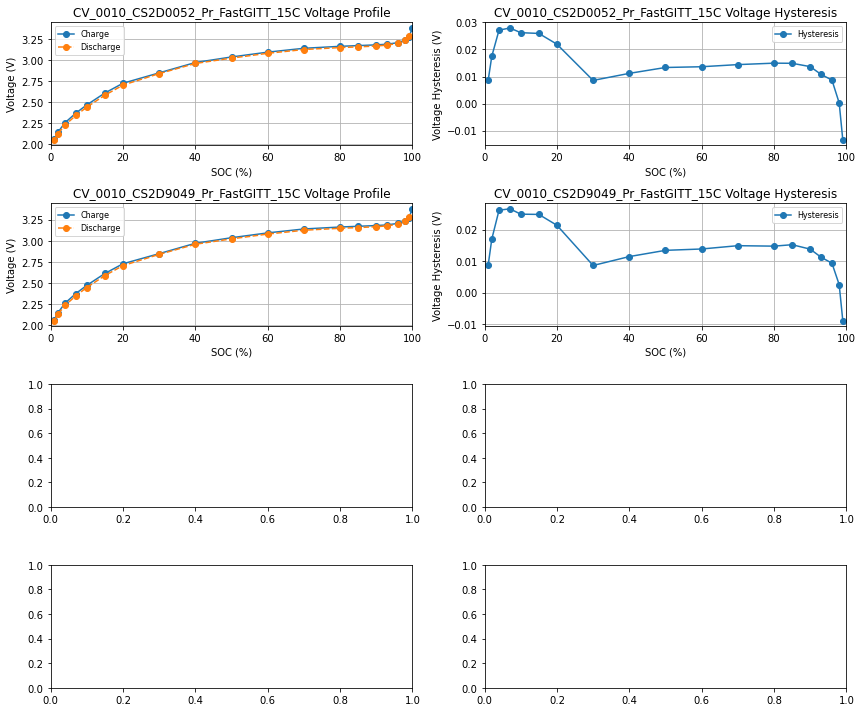

In [8]:
import matplotlib.pyplot as plt

NOMINAL_CAPACITY_AH = 170

if df_hysteresis.empty:
    print("⚠️ No data to plot.")

else:

    test_names = df_hysteresis["test_name"].unique()
    fig, axes = plt.subplots(4, 2, figsize=(12, 10))

    for i, test_name in enumerate(test_names):

        df_test = df_hysteresis[df_hysteresis["test_name"] == test_name].sort_values("soc_percent")

        # Full charge sweep (all SOC points)
        df_charge_all = df_test.dropna(subset=["v_charge_V"])

        # Only points where discharge data also exists
        df_overlap = df_test[df_test["in_both"] == True].sort_values("soc_percent")

        # ----- Left panel: Voltage Profiles -----
        ax_left = axes[i, 0]

        ax_left.plot(
            df_charge_all["soc_percent"],
            df_charge_all["v_charge_V"],
            marker='o',
            linestyle='-',
            label="Charge"
        )
        ax_left.plot(
            df_overlap["soc_percent"],
            df_overlap["v_discharge_V"],
            marker='o',
            linestyle='--',
            label="Discharge"
        )

        ax_left.set_xlabel("SOC (%)")
        ax_left.set_ylabel("Voltage (V)")
        ax_left.set_title(f"{test_name} Voltage Profile")
        ax_left.set_xlim(0, 100)
        ax_left.grid(True)
        ax_left.legend(fontsize=8)

        # ----- Right panel: Voltage Hysteresis -----
        ax_right = axes[i, 1]
        ax_right.plot(
            df_overlap["soc_percent"],
            df_overlap["v_hysteresis_V"],
            marker='o',
            label="Hysteresis"
        )
        ax_right.set_xlabel("SOC (%)")
        ax_right.set_ylabel("Voltage Hysteresis (V)")
        ax_right.set_title(f"{test_name} Voltage Hysteresis")
        ax_right.set_xlim(0, 100)
        ax_right.grid(True)
        ax_right.legend(fontsize=8)

    plt.tight_layout()
    # plt.savefig('FastGITT_CS2D_No100SOC_v1.png', dpi=300)
    plt.show()

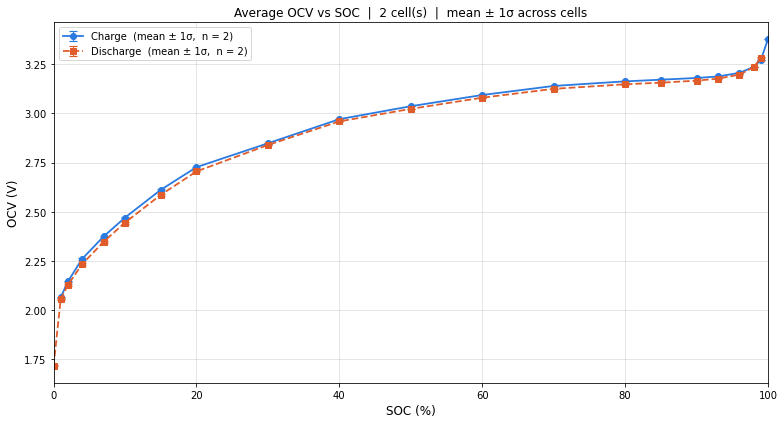

Charge  : 20 SOC steps, 2 cell(s)
Discharge: 20 SOC steps, 2 cell(s)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Average OCV vs SOC — charge & discharge across all loaded cells
# Error bars = 1σ standard deviation across cells at each SOC point
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

if df_hysteresis.empty:
    print("⚠️ No data to plot.")
else:
    n_cells = df_hysteresis["test_name"].nunique()

    # ── Charge: group across all tests at every SOC point ────────────────────
    charge_stats = (
        df_hysteresis
        .dropna(subset=["v_charge_V"])
        .groupby("soc_percent")["v_charge_V"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("soc_percent")
    )
    charge_stats["std"] = charge_stats["std"].fillna(0)

    # ── Discharge: only SOC points where discharge data exists ───────────────
    discharge_stats = (
        df_hysteresis
        .dropna(subset=["v_discharge_V"])
        .groupby("soc_percent")["v_discharge_V"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("soc_percent")
    )
    discharge_stats["std"] = discharge_stats["std"].fillna(0)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.errorbar(
        charge_stats["soc_percent"],
        charge_stats["mean"],
        yerr=charge_stats["std"],
        label=f"Charge  (mean ± 1σ,  n = {n_cells})",
        color="#2A7AE0",
        linestyle="-",
        marker="o",
        capsize=4,
        capthick=1.2,
        elinewidth=1.0,
        linewidth=1.8,
    )

    ax.errorbar(
        discharge_stats["soc_percent"],
        discharge_stats["mean"],
        yerr=discharge_stats["std"],
        label=f"Discharge  (mean ± 1σ,  n = {n_cells})",
        color="#E05C2A",
        linestyle="--",
        marker="s",
        capsize=4,
        capthick=1.2,
        elinewidth=1.0,
        linewidth=1.8,
    )

    ax.set_xlabel("SOC (%)", fontsize=12)
    ax.set_ylabel("OCV (V)", fontsize=12)
    ax.set_title(
        f"Average OCV vs SOC  |  {n_cells} cell(s)  |  mean ± 1σ across cells",
        fontsize=12,
    )
    ax.set_xlim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    # plt.savefig('OCV_Average_AllCells.png', dpi=300)
    plt.show()

    print(f"Charge  : {len(charge_stats)} SOC steps, {n_cells} cell(s)")
    print(f"Discharge: {len(discharge_stats)} SOC steps, {n_cells} cell(s)")
    if n_cells == 1:
        print("Note: only one cell loaded — error bars are zero (no cell-to-cell spread).")

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CSV Export: averaged OCV vs SOC — charge stacked above discharge
# ─────────────────────────────────────────────────────────────────────────────

# Label and rename each table before stacking
charge_export = charge_stats.copy()
charge_export.insert(0, "Direction", "charge")

discharge_export = discharge_stats.copy()
discharge_export.insert(0, "Direction", "discharge")

ocv_export = pd.concat([charge_export, discharge_export], ignore_index=True)

ocv_export.rename(columns={
    "soc_percent": "SOC_pct",
    "mean":        "OCV_mean_V",
    "std":         "OCV_1sigma_stat_V",
    "count":       "N_cells",
}, inplace=True)

ocv_export = ocv_export[["Direction", "SOC_pct", "OCV_mean_V", "OCV_1sigma_stat_V", "N_cells"]]

output_file = "OCV_Average_AllCells_15C_Round2_final.csv"
ocv_export.to_csv(output_file, index=False)

print(f"Exported → '{output_file}'  ({len(ocv_export)} rows)")
print(f"  Charge rows    : {len(charge_export)}")
print(f"  Discharge rows : {len(discharge_export)}")
print()
print("Column legend:")
print("  OCV_mean_V         : mean OCV across all loaded cells at each SOC point")
print("  OCV_1sigma_stat_V  : 1σ standard deviation across cells")
print("  N_cells            : number of cells contributing to each SOC point")

Exported → 'OCV_Average_AllCells_15C_Round2_final.csv'  (40 rows)
  Charge rows    : 20
  Discharge rows : 20

Column legend:
  OCV_mean_V         : mean OCV across all loaded cells at each SOC point
  OCV_1sigma_stat_V  : 1σ standard deviation across cells
  N_cells            : number of cells contributing to each SOC point


In [16]:
# --- Export GITT Hysteresis Data to CSV UTF-8 ---

import os

# Folder to save CSVs (adjust path as needed)
output_folder = "gitt_hysteresis_csvs_HighRez_25C_Final_v1"
os.makedirs(output_folder, exist_ok=True)

if df_hysteresis.empty:
    print("⚠️ No data to export.")

else:
    test_names = df_hysteresis["test_name"].unique()
    
    for test_name in test_names:
        # Extract data for this test
        df_test = df_hysteresis[df_hysteresis["test_name"] == test_name].sort_values("soc_percent")

        # Optionally, add absolute capacity column
        df_test = df_test.copy()
        NOMINAL_CAPACITY_AH = 170
        df_test["capacity_ah"] = df_test["soc_percent"] / 100 * NOMINAL_CAPACITY_AH

        # Create a safe filename
        safe_name = "".join(c if c.isalnum() or c in "_-" else "_" for c in test_name)
        csv_path = os.path.join(output_folder, f"{safe_name}.csv")

        # Export CSV UTF-8
        df_test.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"✅ Exported {csv_path}")

✅ Exported gitt_hysteresis_csvs_HighRez_25C_Final_v1/CV_0010_CS2D9388_Pr_FastGITT_15C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_Final_v1/CV_0010_CS2D8795_Pr_FastGITT_15C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_Final_v1/CV_0010_CS2D8770_Pr_FastGITT_15C.csv
✅ Exported gitt_hysteresis_csvs_HighRez_25C_Final_v1/CV_0010_CS2D9392_Pr_FastGITT_15C.csv
